# 04. Unified Hybrid Pipeline - Quality Defect Explainability

This notebook integrates an Object Detection Model (YOLOv10) with Computer Vision 
techniques (GrabCut, Morphology) to isolate, evaluate, and explain fruit defects.

In [2]:
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Add src to path
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.detection.detector import FruitDetector
from src.grading.grader import QualityGrader
from src.utils.color_analyzer import auto_find_rot_hsv

print("System Dependencies Loaded.")

System Dependencies Loaded.


In [3]:
# Initialize core pipeline classes
model_path = PROJECT_ROOT / "models" / "weights" / "fruit_disease_v1" / "weights" / "best.pt"
detector = FruitDetector(str(model_path))
grader = QualityGrader()

print("AI Architectures Initialized.")

AI Architectures Initialized.


In [4]:
def analyze_fruit_quality(image_path_str):
    """
    End-to-End processing pipeline that visualizes the AI's step-by-step reasoning.
    """
    img_path = Path(image_path_str)
    if not img_path.exists():
        print(f"File does not exist: {img_path}")
        return
        
    print(f"\n--- Analyzing: {img_path.name} ---")
    
    # 1. Detection and Semantic Extraction (YOLO)
    image = cv2.imread(str(img_path))
    bbox, class_name = detector.detect(str(img_path))
    
    if bbox is None:
        print("No object detected in the image!")
        return
        
    print(f"Detected: {class_name}")
    cropped_fruit = detector.crop_image(image, bbox)
    
    # 2. Background Extraction (GrabCut)
    img_no_bg, fruit_mask = grader.remove_background(cropped_fruit)
    
    # 3. K-Means: Automatic Threshold Determination
    lower_hsv, upper_hsv = auto_find_rot_hsv(img_no_bg, k=3)
    
    # 4. Defect Mapping (Morphology & Contours)
    res = grader.find_defects(img_no_bg, fruit_mask, lower_hsv, upper_hsv)
    fruit_area, rot_area, highlighted_img, mask_raw, mask_clean, extracted_rot = res
    
    if fruit_area == 0:
         print("GrabCut Isolation Failed.")
         return
         
    rot_ratio = rot_area / fruit_area
    
    # 5. Rule-Based Classification
    grade, percent = grader.calculate_grade(rot_ratio)
    
    print(f"Total Object Area : {fruit_area} px")
    print(f"Total Defect Area : {rot_area} px")
    print(f"Defect Percentage : {percent:.2f}%")
    print(f"=> Final Verdict  : [{class_name}] - {grade}")
    
    # Display 6 Perspectives in a 2x3 Grid
    plt.figure(figsize=(18, 10))
    plt.suptitle(f"{class_name} Quality Analysis - {percent:.1f}% Defective ({grade})", fontsize=16)
    
    # Perspective 1: Original Crop
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(cropped_fruit, cv2.COLOR_BGR2RGB))
    plt.title("1. AI Crop (YOLO)")
    plt.axis('off')
    
    # Perspective 2: Subject Isolation
    plt.subplot(2, 3, 2)
    plt.imshow(cv2.cvtColor(img_no_bg, cv2.COLOR_BGR2RGB))
    plt.title("2. Isolated Subject (GrabCut)")
    plt.axis('off')
    
    # Perspective 3: Raw Color Thresholding
    plt.subplot(2, 3, 3)
    plt.imshow(mask_raw, cmap='gray')
    plt.title("3. Raw Color Mask (K-Means HSV)")
    plt.axis('off')
    
    # Perspective 4: Morphologically Cleaned Mask
    plt.subplot(2, 3, 4)
    plt.imshow(mask_clean, cmap='gray')
    plt.title("4. Noise Reduced Mask (Morphology)")
    plt.axis('off')
    
    # Perspective 5: Exact Rotten Tissue Extraction
    plt.subplot(2, 3, 5)
    plt.imshow(cv2.cvtColor(extracted_rot, cv2.COLOR_BGR2RGB))
    plt.title("5. Extracted Abnormal Tissue")
    plt.axis('off')
    
    # Perspective 6: Final Contour Highlight
    plt.subplot(2, 3, 6)
    plt.imshow(cv2.cvtColor(highlighted_img, cv2.COLOR_BGR2RGB))
    plt.title("6. Final Bounding Contour")
    plt.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Interactive Test
Provide an explicit image path below to run the visualization pipeline.


--- Analyzing: tao_hong_1.jpg ---

image 1/1 D:\in-class\Advance_AI2\advanced_ai_project\data\test_images\tao_hong_1.jpg: 640x640 1 Apple__Rotten, 6.9ms
Speed: 2.0ms preprocess, 6.9ms inference, 10.6ms postprocess per image at shape (1, 3, 640, 640)
Detected: Apple__Rotten
Total Object Area : 44897 px
Total Defect Area : 12511.0 px
Defect Percentage : 27.87%
=> Final Verdict  : [Apple__Rotten] - Class C (Rejected)


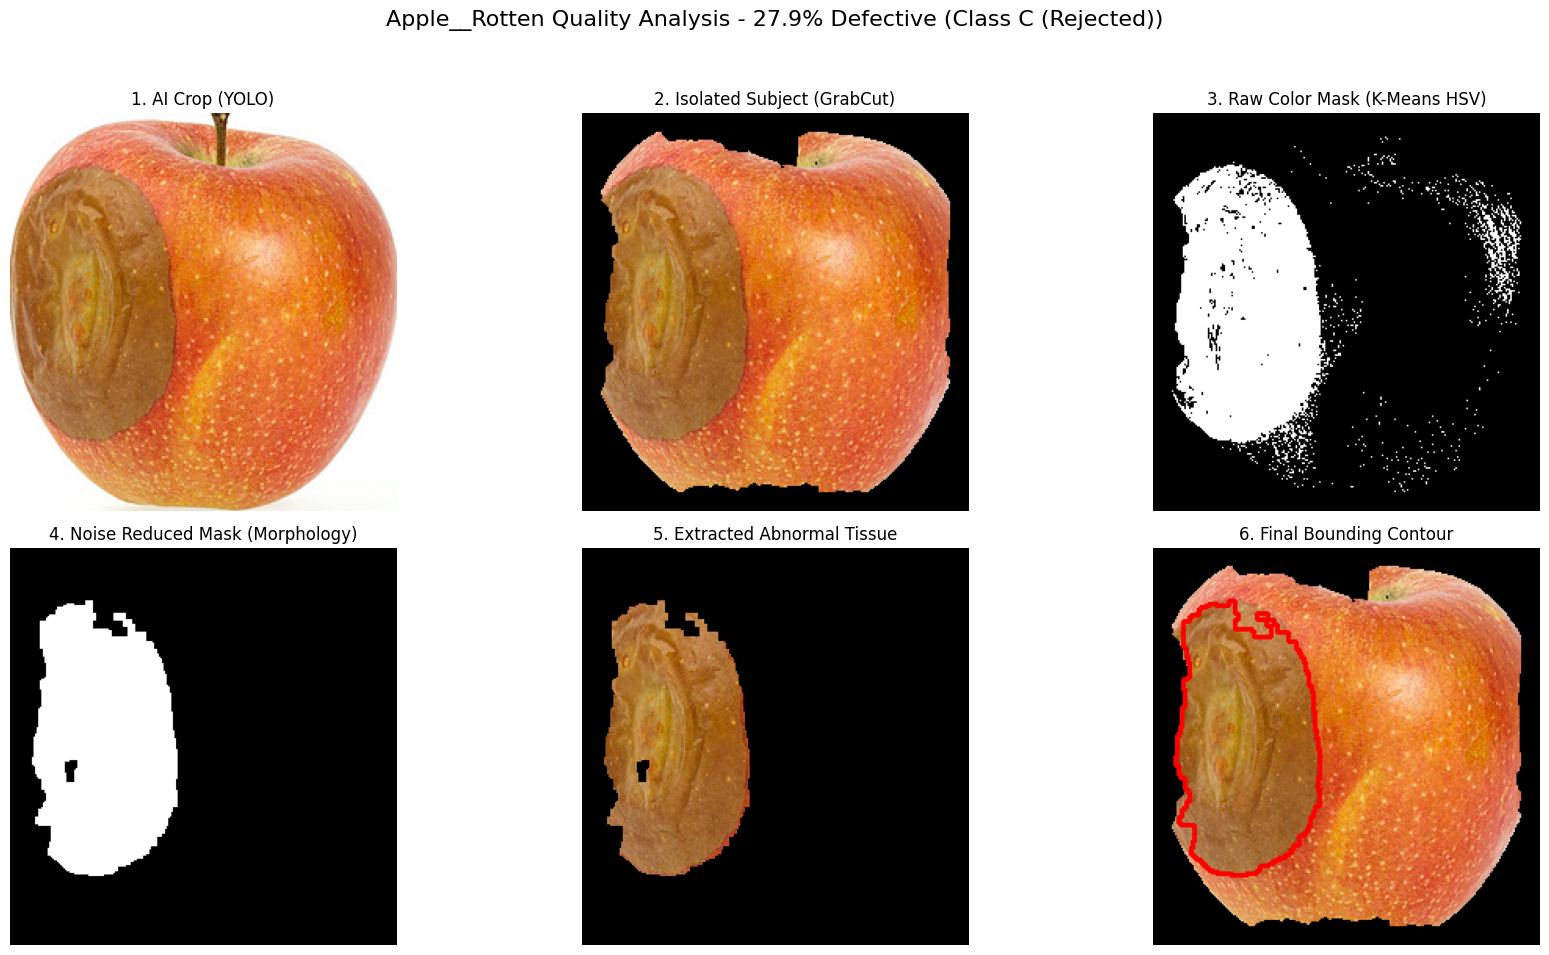

In [5]:
TARGET_IMAGE = str(PROJECT_ROOT / "data" / "test_images" / "tao_hong_1.jpg") # Replace "sample.jpg" with your actual image name

try:
    analyze_fruit_quality(TARGET_IMAGE)
except Exception as e:
    print(f"An error occurred. Check if the path exists. Error: {e}")